# Forty parallel BM4 recurrence trajectories

This notebook integrates **40 independent guiding-centre trajectories** with `BM4Implicit1`. Every trajectory runs for 100 normalized cycles with 40 complete BM4 steps per cycle. The integrations are distributed across worker processes, while each worker is restricted to one internal numerical thread to avoid CPU oversubscription.

The final visualization is one figure containing 40 vertically stacked panels. Panel $i$ measures the minimum-image periodic distance between trajectory $i$ and its own initial position at every later cycle boundary. Cycle zero is omitted because its distance is identically zero.

## Execution note

The parallel worker functions live in an importable project module and use the `spawn` multiprocessing context, making them safe to call from Jupyter. Run the notebook from the beginning. The long integration cell prints a parent-owned status heartbeat every 30 seconds and after each completed trajectory. `worker_count` controls the maximum number of simultaneous trajectories.

In [1]:
import os
from pathlib import Path
from types import SimpleNamespace

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from diagnostics.paths import find_project_root
from potential import load_gc2d_h5_potential
from studies.bm4_parallel_recurrence import (
    ParallelBM4RecurrenceConfig,
    run_parallel_bm4_recurrence,
)
from studies import latin_hypercube_gc_configuration_with_near_center
from visualization import display_records_table
from visualization.bm4_parallel_recurrence import plot_parallel_bm4_recurrence_stack

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})

## Reproducible campaign configuration

In [2]:
# Measured, nondimensionalized GC2D potential.
project_root = find_project_root(Path.cwd())
data_path = project_root / "data/potential/V1/PHI_2.h5"
magnetic_field = 1.5
characteristic_length = 0.06
mode_selection = (0, 1)
interpolation_order = 3

# Forty reproducible Latin-hypercube positions. Trajectory 1 preserves the
# near-centre initial point studied in the preceding recurrence notebook.
particle_count = 40
initial_condition_seed = 20260905
domain_margin_fraction = 0.05
near_center_offset_fraction = (0.08, -0.06)

# Requested lower-resolution BM4 campaign.
cycle_count = 100
steps_per_cycle = 40
saved_samples_per_cycle = 1
t_span = (0.0, float(cycle_count))
rho = 0.3
coupling_frequency = float(np.pi / 8.0)
newton_absolute_tolerance = 1e-12
newton_relative_tolerance = 1e-11
newton_max_iterations = 40
jacobian_relative_step = float(np.cbrt(np.finfo(float).eps))

# Use at most eight processes by default; increase this only when memory and
# physical CPU cores permit forty worker-local potential interpolators.
available_cpu_count = os.cpu_count() or 1
worker_count = min(8, available_cpu_count, particle_count)
recurrence_tolerance_fraction = 0.01

if not data_path.is_file():
    raise FileNotFoundError(f"Measured HDF5 potential not found: {data_path}")
potential = load_gc2d_h5_potential(
    data_path,
    B=magnetic_field,
    characteristic_length=characteristic_length,
    indx=mode_selection,
    interpolation_order=interpolation_order,
)
initial_configuration = latin_hypercube_gc_configuration_with_near_center(
    potential,
    particle_count=particle_count,
    seed=initial_condition_seed,
    center_offset_fraction=near_center_offset_fraction,
    domain_margin_fraction=domain_margin_fraction,
)
config = ParallelBM4RecurrenceConfig(
    particle_count=particle_count,
    t_span=t_span,
    steps_per_cycle=steps_per_cycle,
    saved_samples_per_cycle=saved_samples_per_cycle,
    rho=rho,
    coupling_frequency=coupling_frequency,
    absolute_tolerance=newton_absolute_tolerance,
    relative_tolerance=newton_relative_tolerance,
    max_iterations=newton_max_iterations,
    jacobian_relative_step=jacobian_relative_step,
    worker_count=worker_count,
    progress=True,
)
assert config.cycle_count == 100
assert config.step_count == 4_000
assert config.output_sample_count == 101
assert config.integration_step == 0.025
assert config.worker_count >= 1
display(Markdown(
    f"**Resolved campaign:** `{particle_count}` trajectories, `{config.step_count}` "
    f"steps per trajectory, $\Delta t={config.integration_step:g}$, "
    f"`{config.output_sample_count}` cycle-boundary states and "
    f"`{config.worker_count}` worker processes."
))

**Resolved campaign:** `40` trajectories, `4000` steps per trajectory, $\Delta t=0.025$, `101` cycle-boundary states and `8` worker processes.

## Initial-condition coverage

The seeded Latin-hypercube design distributes all 40 initial points across the periodic cell. Trajectory 1 is replaced by the previously studied near-centre point and is marked with a star.

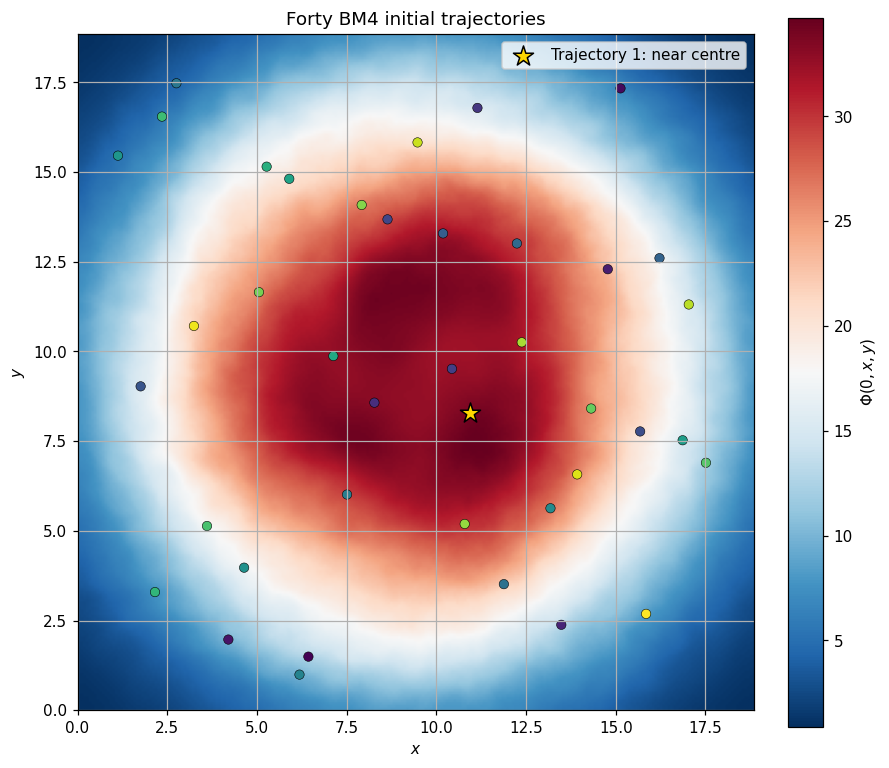

In [3]:
initial_state = initial_configuration.initial_state
assert initial_state is not None
initial_x, initial_y = initial_configuration.positions(initial_state)
grid = potential.grid
field_at_zero = np.asarray(potential.evaluate(0.0), dtype=float)
figure, axis = plt.subplots(figsize=(8, 7), constrained_layout=True)
image = axis.imshow(
    field_at_zero.T,
    origin="lower",
    extent=(grid.xmin, grid.xmin + grid.period, grid.ymin, grid.ymin + grid.period),
    cmap="RdBu_r",
    aspect="equal",
)
scatter = axis.scatter(
    initial_x[1:], initial_y[1:], c=np.arange(2, particle_count + 1),
    cmap="viridis", s=38, edgecolor="black", linewidth=0.35,
)
axis.scatter(
    initial_x[0], initial_y[0], marker="*", s=190, color="gold",
    edgecolor="black", label="Trajectory 1: near centre",
)
axis.set(title="Forty BM4 initial trajectories", xlabel="$x$", ylabel="$y$")
axis.legend()
figure.colorbar(image, ax=axis, label="$\Phi(0,x,y)$")
plt.show()

## Parallel BM4 integrations

This cell launches 40 independent process tasks. Every task integrates one particle for all 100 cycles and returns only its 101 cycle-boundary positions plus compact Newton-work summaries.

In [4]:
result = run_parallel_bm4_recurrence(
    potential,
    initial_configuration,
    config=config,
)

Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 0.0 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 48.2 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 78.2 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 108.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 138.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 168.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 198.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 228.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 258.3 s; ETA after first completion.
Parallel BM4 recurrence: 0/40 trajectories; workers 8; elapsed 288.3 s; ETA after first completion.
Para

## Result and worker audit

In [5]:
assert result.positions.shape == (40, 2, 101)
assert result.initial_positions.shape == (40, 2)
assert result.runtime_seconds.shape == (40,)
assert result.total_newton_iterations.shape == (40,)
np.testing.assert_allclose(result.times, np.arange(101, dtype=float))
assert np.all(result.maximum_residual_to_tolerance <= 1.0)
display(Markdown(
    f"All **{particle_count} trajectories** completed in "
    f"**{result.wall_runtime_seconds:.1f} s wall time** with "
    f"{config.worker_count} worker processes."
))

All **40 trajectories** completed in **13033.2 s wall time** with 8 worker processes.

## Forty vertically stacked recurrence plots

Each panel uses a logarithmic vertical scale and omits cycle zero. The dashed line is the configurable close-return threshold. The red point marks that trajectory's closest later cycle boundary.

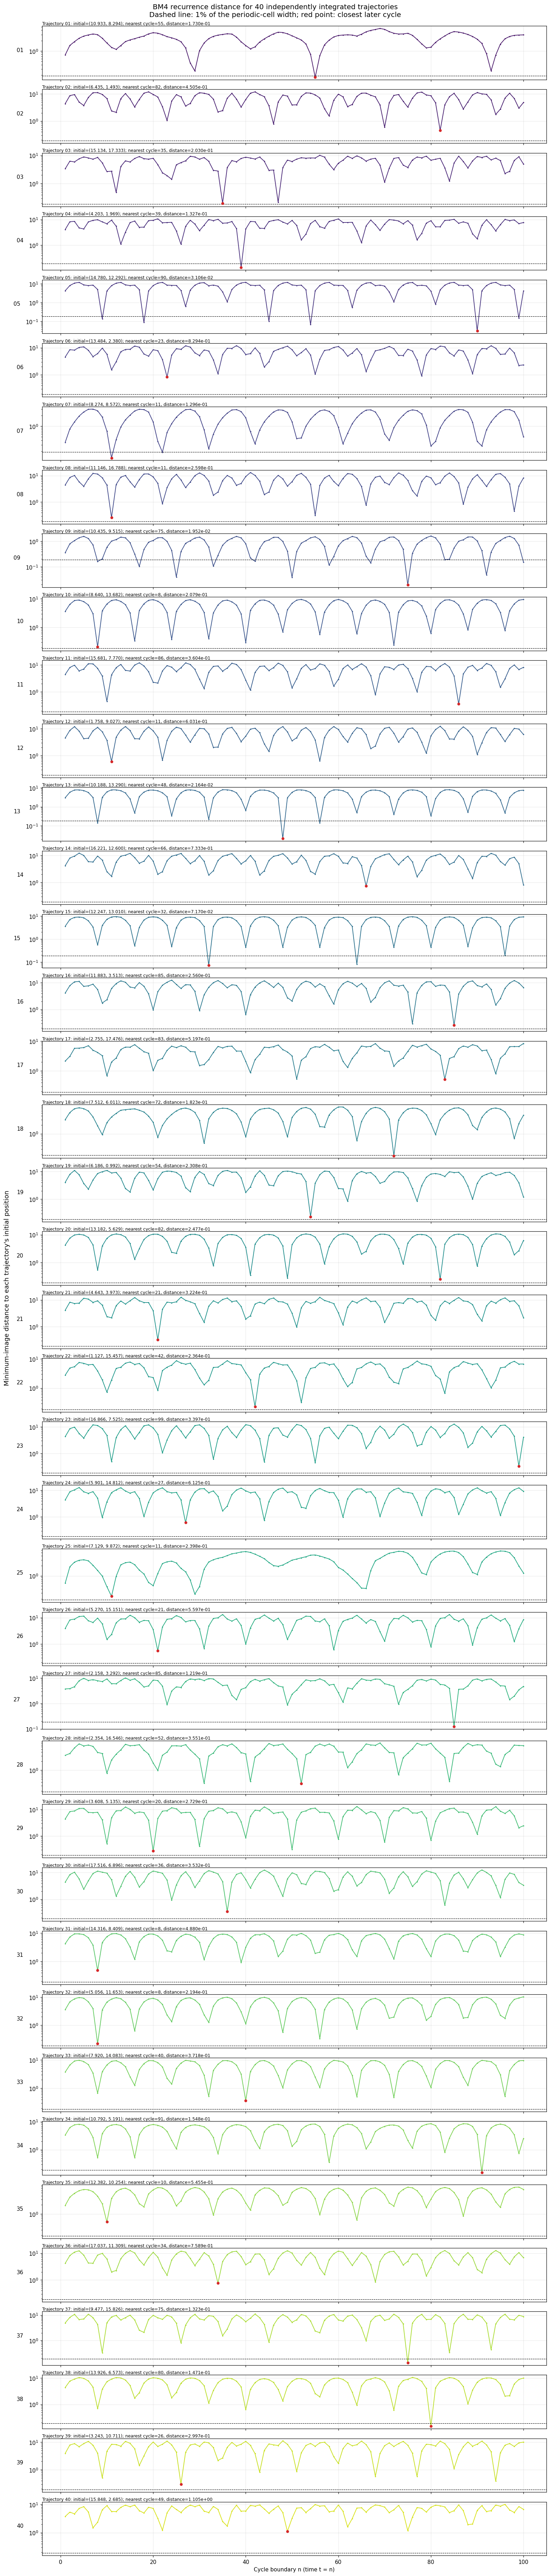

In [6]:
recurrence_figure, recurrence_axes = plot_parallel_bm4_recurrence_stack(
    result,
    period=potential.grid.period,
    recurrence_tolerance_fraction=recurrence_tolerance_fraction,
)
assert recurrence_axes.shape == (40,)
plt.show()

## Closest return for every trajectory

This compact table mirrors the red point in each of the 40 panels and counts all cycle boundaries within the chosen recurrence threshold.

In [7]:
cell_period = float(potential.grid.period)
recurrence_tolerance = recurrence_tolerance_fraction * cell_period
distances = result.recurrence_distances(period=cell_period)
nearest_rows = []
for particle in range(particle_count):
    nearest_index = int(np.argmin(distances[particle, 1:]) + 1)
    close_cycles = np.flatnonzero(distances[particle, 1:] <= recurrence_tolerance) + 1
    nearest_rows.append(SimpleNamespace(
        trajectory=particle + 1,
        initial_x=result.initial_positions[particle, 0],
        initial_y=result.initial_positions[particle, 1],
        nearest_cycle=int(round(result.times[nearest_index])),
        nearest_distance=distances[particle, nearest_index],
        cell_fraction=distances[particle, nearest_index] / cell_period,
        close_return_count=close_cycles.size,
    ))
display_records_table(
    tuple(nearest_rows),
    columns=(
        ("trajectory", "Trajectory", "d"),
        ("initial_x", "Initial x", ".6f"),
        ("initial_y", "Initial y", ".6f"),
        ("nearest_cycle", "Nearest cycle", "d"),
        ("nearest_distance", "Nearest distance", ".5e"),
        ("cell_fraction", "Cell-width fraction", ".5e"),
        ("close_return_count", "Close-return cycles", "d"),
    ),
)

Trajectory,Initial x,Initial y,Nearest cycle,Nearest distance,Cell-width fraction,Close-return cycles
1,10.932742,8.293805,55,1.73027e-01,9.17939e-03,1
2,6.434545,1.492704,82,4.50542e-01,2.39020e-02,0
3,15.133839,17.333398,35,2.03031e-01,1.07711e-02,0
4,4.203492,1.968996,39,1.32745e-01,7.04236e-03,1
5,14.779982,12.292243,90,3.10610e-02,1.64784e-03,6
6,13.483935,2.380199,23,8.29390e-01,4.40005e-02,0
7,8.273719,8.572108,11,1.29607e-01,6.87587e-03,2
8,11.146490,16.787661,11,2.59843e-01,1.37851e-02,0
9,10.435200,9.515324,75,1.95178e-02,1.03545e-03,11
10,8.639722,13.681724,8,2.07894e-01,1.10291e-02,0


## Per-trajectory runtime and Newton work

In [8]:
work_rows = tuple(
    SimpleNamespace(
        trajectory=particle + 1,
        runtime=result.runtime_seconds[particle],
        mean_iterations=result.mean_newton_iterations[particle],
        maximum_iterations=result.maximum_newton_iterations[particle],
        total_iterations=result.total_newton_iterations[particle],
        maximum_residual_ratio=result.maximum_residual_to_tolerance[particle],
    )
    for particle in range(particle_count)
)
display_records_table(
    work_rows,
    columns=(
        ("trajectory", "Trajectory", "d"),
        ("runtime", "Worker runtime [s]", ".3f"),
        ("mean_iterations", "Mean corrections/step", ".3f"),
        ("maximum_iterations", "Max corrections/step", "d"),
        ("total_iterations", "Total corrections", "d"),
        ("maximum_residual_ratio", "Max residual/tolerance", ".3e"),
    ),
)

Trajectory,Worker runtime [s],Mean corrections/step,Max corrections/step,Total corrections,Max residual/tolerance
1,2219.871,0.999,1,3997,9.299e-01
2,2313.081,1.010,2,4040,9.701e-01
3,2210.990,1.000,1,4000,8.330e-01
4,2306.444,1.004,2,4014,9.491e-01
5,2375.155,1.060,2,4238,9.955e-01
6,2266.993,1.028,2,4113,9.967e-01
7,2289.776,0.994,1,3975,9.812e-01
8,2197.486,1.028,2,4114,9.923e-01
9,2390.620,0.995,1,3979,9.804e-01
10,2457.712,1.008,2,4031,9.644e-01


## Data-driven campaign summary

In [9]:
best_particle, best_cycle = np.unravel_index(
    np.argmin(distances[:, 1:]),
    distances[:, 1:].shape,
)
best_cycle += 1
close_particle_count = int(np.sum(np.any(distances[:, 1:] <= recurrence_tolerance, axis=1)))
display(Markdown("\n".join((
    f"- **Closest return in the campaign:** trajectory {best_particle + 1} at cycle {best_cycle}, distance `{distances[best_particle, best_cycle]:.6e}`.",
    f"- **Trajectories with at least one close return:** {close_particle_count}/{particle_count}.",
    f"- **Parallel wall time:** {result.wall_runtime_seconds:.1f} s with {config.worker_count} workers.",
    f"- **Sum of isolated worker runtimes:** {np.sum(result.runtime_seconds):.1f} s.",
))))

- **Closest return in the campaign:** trajectory 9 at cycle 75, distance `1.951783e-02`.
- **Trajectories with at least one close return:** 12/40.
- **Parallel wall time:** 13033.2 s with 8 workers.
- **Sum of isolated worker runtimes:** 102199.3 s.